# An Exploratory Data Analysis of Nutrition and Physical Activity Factors Associated with Obesity in the U.S.

Group 3
- ⁠Faiyaz Ahmad (0872860)
- ⁠Chinenye Alice Anieke (0864234)
- ⁠Qianru Deng (0839710)
- ⁠Damola Emmanuel Olayemi (0868981)
- ⁠Jie Zhang (0879447)


## 1. Data Dictionary

This section provides an overview of the dataset columns, their descriptions, and data types (based on initial inspection).

| Column | Description | Data Type | Non-Null Count |
|--------|-------------|-----------|----------------|
| YearStart | Starting year of the data record | int64 | 110880 |
| YearEnd | Ending year of the data record | int64 | 110880 |
| LocationAbbr | Abbreviation of the location (e.g., state) | object | 110880 |
| LocationDesc | Full description of the location | object | 110880 |
| Datasource | Source of the data (e.g., BRFSS) | object | 110880 |
| Class | Category of the health measure (e.g., Obesity / Weight Status) | object | 110880 |
| Topic | Specific topic within the class (e.g., Obesity) | object | 110880 |
| Question | The survey question | object | 110880 |
| Data_Value_Unit | Unit of the data value (e.g., %) | object | 4620 |
| Data_Value_Type | Type of value (e.g., Percentage) | object | 110880 |
| Data_Value | Main value (e.g., obesity prevalence %) | float64 | 97666 |
| Data_Value_Alt | Alternative representation of Data_Value | float64 | 97666 |
| Data_Value_Footnote_Symbol | Symbol for footnotes | object | 13214 |
| Data_Value_Footnote | Footnote text | object | 13214 |
| Low_Confidence_Limit | Lower confidence interval | float64 | 97666 |
| High_Confidence_Limit | Upper confidence interval | float64 | 97666 |
| Sample_Size | Sample size for the estimate | object | 97666 |
| Total | Total category (for unstratified) | object | 3960 |
| Age(years) | Age stratification | object | 23760 |
| Education | Education stratification | object | 15840 |
| Sex | Sex stratification | object | 7920 |
| Income | Income stratification | object | 27720 |
| Race/Ethnicity | Race/Ethnicity stratification | object | 31680 |
| GeoLocation | Geographic coordinates | object | 108864 |
| ClassID | ID for Class | object | 110880 |
| TopicID | ID for Topic | object | 110880 |
| QuestionID | ID for Question | object | 110880 |
| DataValueTypeID | ID for Data_Value_Type | object | 110880 |
| LocationID | ID for Location | int64 | 110880 |
| StratificationCategory1 | Primary stratification category (e.g., Age, Income) | object | 110880 |
| Stratification1 | Specific stratification value | object | 110880 |
| StratificationCategoryId1 | ID for StratificationCategory1 | object | 110880 |
| StratificationID1 | ID for Stratification1 | object | 110880 |

## 2. Data Understanding & Preparation

### 2.1 Data Understanding

#### Import Libraries

In [12]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
#import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns
import warnings
from statsmodels.stats.multicomp import pairwise_tukeyhsd
warnings.filterwarnings('ignore')

Load Dataset

In [14]:
## Load BRFSS obesity dataset

data=pd.read_csv(r'/content/Nutrition,_Physical_Activity,_and_Obesity_-_Behavioral_Risk_Factor_Surveillance_System_20260123.csv')
data.columns = data.columns.str.strip().str.replace(r'\s+', '_', regex=True)

####Dataset Overview


In [15]:
# Inspect dataset structure and data types

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110880 entries, 0 to 110879
Data columns (total 33 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   YearStart                   110880 non-null  int64  
 1   YearEnd                     110880 non-null  int64  
 2   LocationAbbr                110880 non-null  object 
 3   LocationDesc                110880 non-null  object 
 4   Datasource                  110880 non-null  object 
 5   Class                       110880 non-null  object 
 6   Topic                       110880 non-null  object 
 7   Question                    110880 non-null  object 
 8   Data_Value_Unit             4620 non-null    object 
 9   Data_Value_Type             110880 non-null  object 
 10  Data_Value                  97666 non-null   float64
 11  Data_Value_Alt              97666 non-null   float64
 12  Data_Value_Footnote_Symbol  13214 non-null   object 
 13  Data_Value_Foo

In [16]:
#Show shape

print(f"Shape of the dataset: {data.shape}")

Shape of the dataset: (110880, 33)


In [17]:
#show first 5 rows

data.head(5)

,YearStart,YearEnd,LocationAbbr,LocationDesc,Datasource,Class,Topic,Question,Data_Value_Unit,Data_Value_Type,...,GeoLocation,ClassID,TopicID,QuestionID,DataValueTypeID,LocationID,StratificationCategory1,Stratification1,StratificationCategoryId1,StratificationID1
0,2011,2011,AL,Alabama,Behavioral Risk Factor Surveillance System,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,NaN,Value,...,"(32.840571122, -86.631860762)",OWS,OWS1,Q036,VALUE,1,Income,"$15,000 - $24,999",INC,INC1525
1,2011,2011,AL,Alabama,Behavioral Risk Factor Surveillance System,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,NaN,Value,...,"(32.840571122, -86.631860762)",OWS,OWS1,Q036,VALUE,1,Income,"$25,000 - $34,999",INC,INC2535
2,2011,2011,AL,Alabama,Behavioral Risk Factor Surveillance System,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,NaN,Value,...,"(32.840571122, -86.631860762)",OWS,OWS1,Q036,VALUE,1,Income,"$35,000 - $49,999",INC,INC3550
3,2011,2011,AL,Alabama,Behavioral Risk Factor Surveillance System,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,NaN,Value,...,"(32.840571122, -86.631860762)",OWS,OWS1,Q036,VALUE,1,Income,"$50,000 - $74,999",INC,INC5075
4,2011,2011,AL,Alabama,Behavioral Risk Factor Surveillance System,Obesity / Weight Status,Obesity / Weight Status,Percent of adults aged 18 years and older who ...,NaN,Value,...,"(32.840571122, -86.631860762)",OWS,OWS1,Q036,VALUE,1,Income,"$75,000 or greater",INC,INC75PLUS


#### Missing values Overview

In [18]:
# Assess missing values to distinguish structural vs analytical gaps

missing_info = pd.DataFrame({
    "Missing Count": data.isnull().sum(),
    "Missing Percentage": (data.isnull().sum() / len(data)) * 100
}).query("`Missing Count` > 0").sort_values("Missing Percentage", ascending=False)

missing_info

,Missing Count,Missing Percentage
Total,106920,96.428571
Data_Value_Unit,106260,95.833333
Sex,102960,92.857143
Data_Value_Footnote,97666,88.082612
Data_Value_Footnote_Symbol,97666,88.082612
Education,95040,85.714286
Age(years),87120,78.571429
Income,83160,75.000000
Race/Ethnicity,79200,71.428571
Data_Value,13214,11.917388


In [19]:
data['Income']

,Income
0,"$15,000 - $24,999"
1,"$25,000 - $34,999"
2,"$35,000 - $49,999"
3,"$50,000 - $74,999"
4,"$75,000 or greater"
...,...
110875,NaN
110876,NaN
110877,NaN
110878,NaN


Check for Duplicate Rows

In [20]:
# Check for duplicate rows

print(f"Number of duplicated rows: {data.duplicated().sum()}")

Number of duplicated rows: 0


#### Column roles and BRFSS long-format structure

Each row represents one health measure for one location and year, reported for a single population stratification.

- Outcome: Data_Value (obesity prevalence %)
- Reliability: Sample_Size, Low_Confidence_Limit, High_Confidence_Limit
- Identifiers: Class, Topic, Question, and IDs
- Time & Geography: YearStart, YearEnd, LocationAbbr, LocationDesc
- Stratification: StratificationCategory1, Stratification1

High missingness in stratification columns is expected due to long-format reporting (one stratification per row).


Cardinality / Uniqueness Check

In [21]:
# Cardinality (unique values) check
unique_values = data.nunique()
unique_values

,0
YearStart,14
YearEnd,14
LocationAbbr,55
LocationDesc,55
Datasource,1
Class,3
Topic,3
Question,9
Data_Value_Unit,1
Data_Value_Type,1


Stratification Structure Analysis

In [22]:
strat_map = {
    "Income": "Income",
    "Education": "Education",
    "Sex": "Sex",
    "Race/Ethnicity": "Race/Ethnicity",
    "Age (years)": "Age(years)"
}

strat_counts = data["StratificationCategory1"].value_counts(dropna=False)

# Missing rate in expected column for each stratification
rows = []
for strat_cat, expected_col in strat_map.items():
    sub = data[data["StratificationCategory1"] == strat_cat]
    if len(sub) > 0:
        missing_rate = (sub[expected_col].isna().mean() * 100).round(2)
        rows.append({"StratificationCategory1": strat_cat, "expected_column": expected_col,
                     "rows_in_category": len(sub), "missing_rate_in_expected_column_%": missing_rate})

structural_missingness_check = pd.DataFrame(rows).sort_values("missing_rate_in_expected_column_%", ascending=False)
structural_missingness_check

,StratificationCategory1,expected_column,rows_in_category,missing_rate_in_expected_column_%
0,Income,Income,27720,0.0
1,Education,Education,15840,0.0
2,Sex,Sex,7920,0.0
3,Race/Ethnicity,Race/Ethnicity,31680,0.0
4,Age (years),Age(years),23760,0.0


Validity Checks for Numeric Fields

In [23]:
# Percentage range check (0-100)
def pct_out_of_range(df, col):
    if col not in df.columns: return pd.DataFrame()
    bad = df[df[col].notna() & ((df[col] < 0) | (df[col] > 100))].copy()
    keep_cols = ["YearStart", "LocationAbbr", "QuestionID", col]
    keep_cols = [c for c in keep_cols if c in bad.columns]
    return bad[keep_cols]

print("Out-of-range Data_Value rows:", len(pct_out_of_range(data, "Data_Value")))               # 0
print("Out-of-range Low_Confidence_Limit rows:", len(pct_out_of_range(data, "Low_Confidence_Limit")))  # 0
print("Out-of-range High_Confidence_Limit rows:", len(pct_out_of_range(data, "High_Confidence_Limit"))) # 0

# Confidence interval logic check
ci_issues = data[
    data["Data_Value"].notna() &
    data["Low_Confidence_Limit"].notna() &
    data["High_Confidence_Limit"].notna() &
    ((data["Low_Confidence_Limit"] > data["High_Confidence_Limit"]) |
     (data["Data_Value"] < data["Low_Confidence_Limit"]) |
     (data["Data_Value"] > data["High_Confidence_Limit"]))
]
print("CI logic issue rows:", len(ci_issues))  # 0

Out-of-range Data_Value rows: 0
Out-of-range Low_Confidence_Limit rows: 0
Out-of-range High_Confidence_Limit rows: 0
CI logic issue rows: 0


Uniqueness Check Using Candidate Key


In [24]:
candidate_key = ["YearStart", "LocationAbbr", "QuestionID", "StratificationCategory1", "Stratification1"]
dup_by_key = data.duplicated(subset=candidate_key).sum()
dup_by_key

np.int64(0)

### 2.2 Data Preparation
#### Type conversion and standardization


In [25]:
# remove spaces of column names
data.columns = data.columns.str.strip()

# Standardize data types for analysis

text_cols = [
    "LocationAbbr", "LocationDesc", "Datasource", "Class", "Topic", "Question",
    "Data_Value_Type", "Data_Value_Unit",
    "StratificationCategory1", "Stratification1",
    "Total", "Age(years)", "Education", "Sex", "Income", "Race/Ethnicity"
]
for col in text_cols:
    if col in data.columns:
        data[col] = data[col].astype("string").str.strip()

numeric_cols = [
    'YearStart', 'YearEnd',
    'Data_Value', 'Data_Value_Alt',
    'Low_Confidence_Limit', 'High_Confidence_Limit',
    'Sample_Size'
]

for col in numeric_cols:
    data[col] = pd.to_numeric(data[col], errors='coerce')


In [26]:
# calculate missing rate in the expected column
rows = []

for strat_cat, expected_col in strat_map.items():
    # skip if columns are missing
    if "StratificationCategory1" not in data.columns or expected_col not in data.columns:
        continue

    # subset rows for this stratification category
    sub = data[data["StratificationCategory1"] == strat_cat]
    if len(sub) == 0:
        continue

    missing_rate = (sub[expected_col].isna().mean() * 100).round(2)

    rows.append({
        "StratificationCategory1": strat_cat,
        "expected_column": expected_col,
        "rows_in_category": len(sub),
        "missing_rate_in_expected_column_%": missing_rate
    })
missing_rate

np.float64(0.0)

Summary Statistics for Key Numeric Variables

In [27]:
# Summary statistics for key numeric variables
data[[
    "Data_Value",
    "Sample_Size",
    "Low_Confidence_Limit",
    "High_Confidence_Limit"
]].describe()


,Data_Value,Sample_Size,Low_Confidence_Limit,High_Confidence_Limit
count,97666.000000,46387.000000,97666.000000,97666.000000
mean,31.800252,471.194559,27.395236,36.767070
std,10.343087,280.450748,10.130335,11.282278
min,0.900000,50.000000,0.300000,3.000000
25%,24.900000,212.000000,20.400000,29.200000
50%,31.800000,468.000000,27.300000,36.500000
75%,37.400000,706.000000,33.300000,42.800000
max,85.300000,999.000000,74.700000,92.400000


#### Analytical Scoping & Dataset Filtering


In [28]:
# Define the target obesity question
target_question = "Percent of adults aged 18 years and older who have obesity"

# Filter dataset to the selected question
df_obesity = data[
    (data["Question"] == target_question) &
    (data["Data_Value"].notna())
].copy()

print("Filtered dataset shape:", df_obesity.shape)

# Filter to income-based stratification
df_income = df_obesity[
    df_obesity["StratificationCategory1"] == "Income"
].copy()

print("Income-stratified dataset shape:", df_income.shape)

Filtered dataset shape: (19078, 33)
Income-stratified dataset shape: (5256, 33)


####Export Clean, Analysis-Ready Files

In [29]:
# Clean long-format core file
df_obesity.to_csv("clean_core.csv", index=False)

# wide-format file (Income disparities)
clean_income_wide = (
    df_income
    .pivot_table(
        index=["YearStart", "LocationDesc"],
        columns="Stratification1",
        values="Data_Value"
    )
    .reset_index()
)

clean_income_wide.to_csv("clean_obesity_income_wide.csv", index=False)

clean_df = df_obesity.copy()
clean_income_df = df_income.copy()

## 3. EDA

### 3.1 Basic EDA

#### 3.1.1 UNIVARIATE ANALYSIS

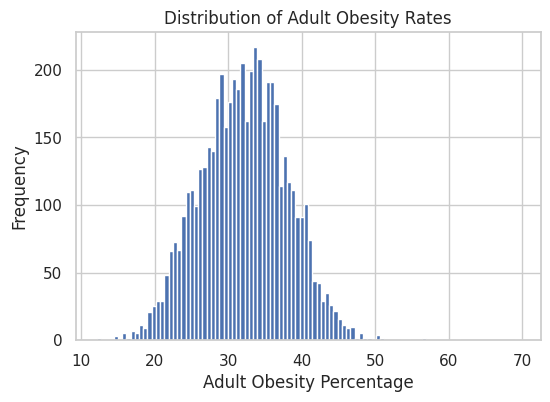

In [74]:
#Obesity Distribution

plt.figure(figsize=(6,4))
plt.hist(clean_df["Data_Value"], bins=100)
plt.xlabel("Adult Obesity Percentage")
plt.ylabel("Frequency")
plt.title("Distribution of Adult Obesity Rates")
plt.show()


In [75]:
clean_df["Data_Value"].describe()


,Data_Value
count,5256.000000
mean,32.112215
std,5.922218
min,12.100000
25%,28.000000
50%,32.200000
75%,36.125000
max,69.600000


#### 3.1.2 BIVARIATE ANALYSIS

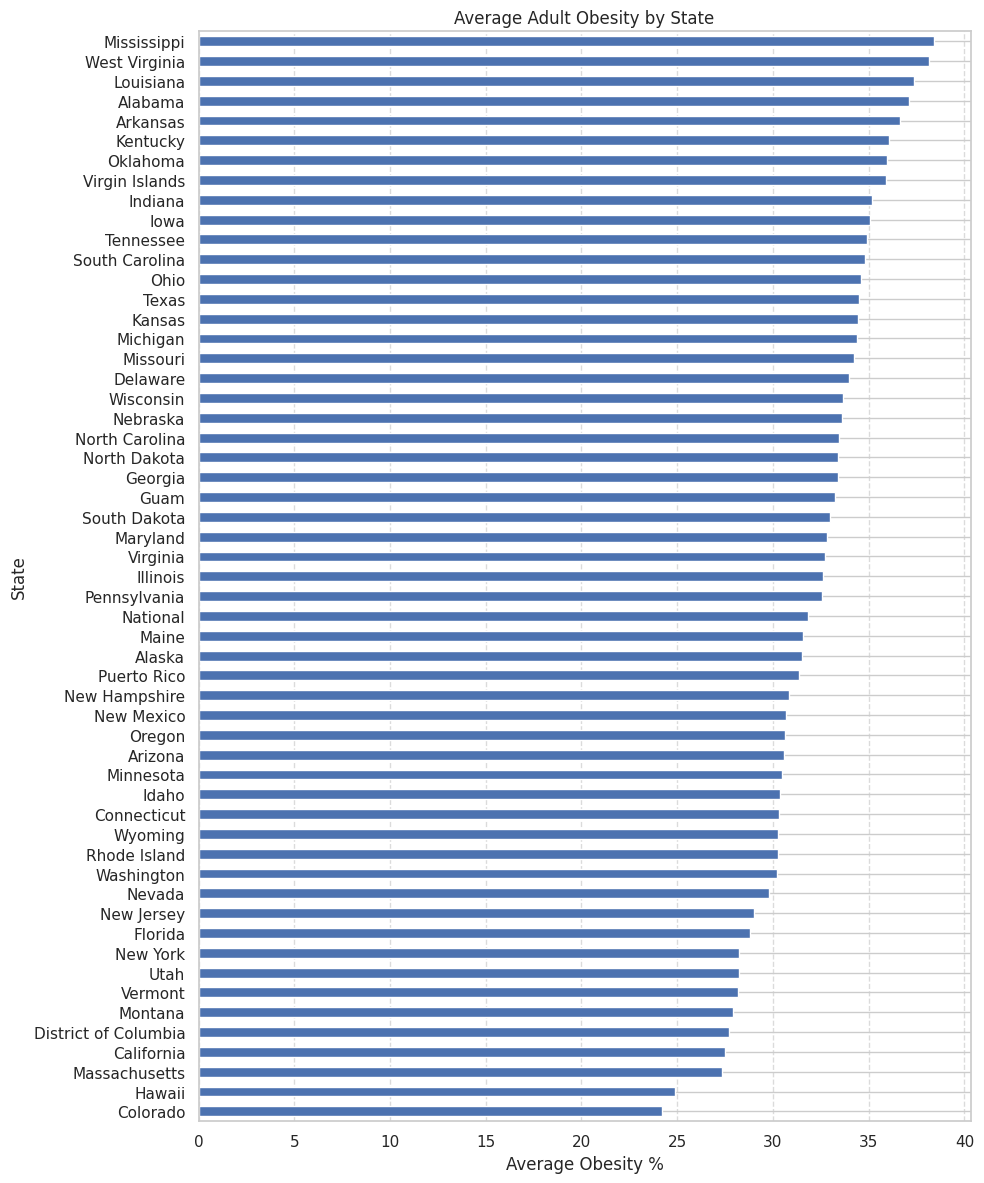

In [76]:
import matplotlib.pyplot as plt

# Obesity by State

state_avg = clean_df.groupby("LocationDesc")["Data_Value"].mean().sort_values(ascending=True)

plt.figure(figsize=(10, 12))  # Increased figure size for better readability
state_avg.plot(kind="barh")
plt.xlabel("Average Obesity %")
plt.ylabel("State") # Added y-axis label
plt.title("Average Adult Obesity by State")
plt.grid(axis='x', linestyle='--', alpha=0.7) # Added grid lines
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

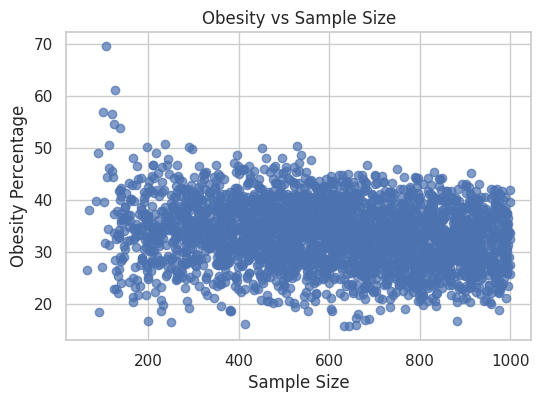

In [77]:
# Obesity vs Sample Size

plt.figure(figsize=(6,4))
plt.scatter(clean_df["Sample_Size"], clean_df["Data_Value"], alpha=0.7)
plt.xlabel("Sample Size")
plt.ylabel("Obesity Percentage")
plt.title("Obesity vs Sample Size")
plt.show()


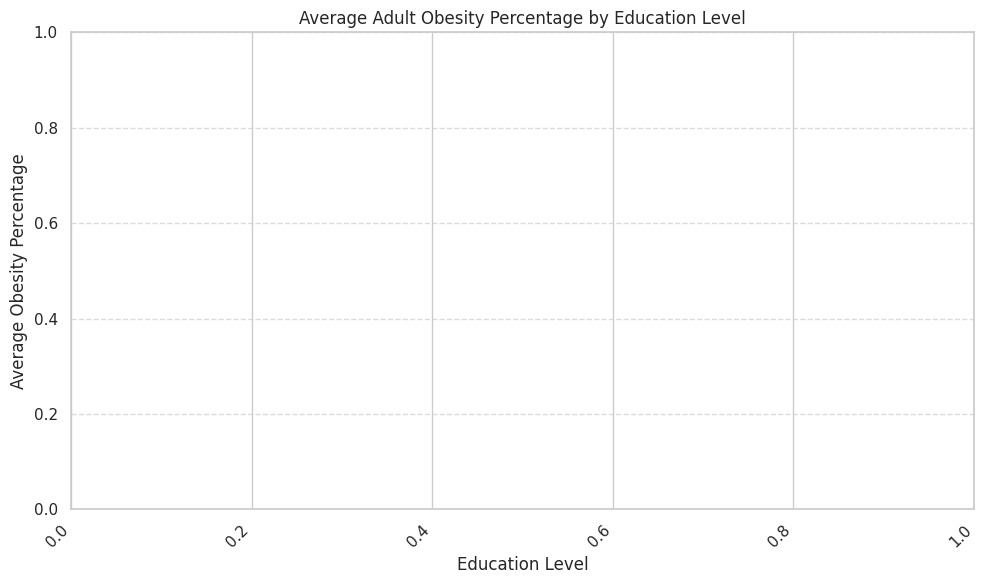

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by education level and calculate the mean obesity percentage
obesity_by_education = clean_df[clean_df['StratificationCategory1'] == 'Education'].groupby('Stratification1')['Data_Value'].mean().sort_values(ascending=False)

# Create the bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x=obesity_by_education.index, y=obesity_by_education.values, palette='viridis')
plt.xlabel("Education Level")
plt.ylabel("Average Obesity Percentage")
plt.title("Average Adult Obesity Percentage by Education Level")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

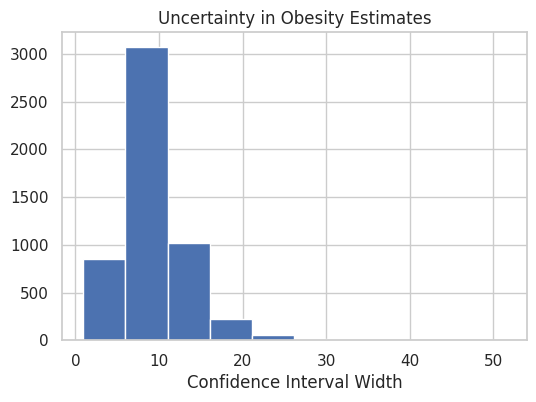

In [79]:
# Confidence Interval Analysis

clean_df["CI_Width"] = clean_df["High_Confidence_Limit"] - clean_df["Low_Confidence_Limit"]

plt.figure(figsize=(6,4))
plt.hist(clean_df["CI_Width"], bins=10)
plt.xlabel("Confidence Interval Width")
plt.title("Uncertainty in Obesity Estimates")
plt.show()

#### 3.1.3 MULTIVARIATE / PATTERN ANALYSIS

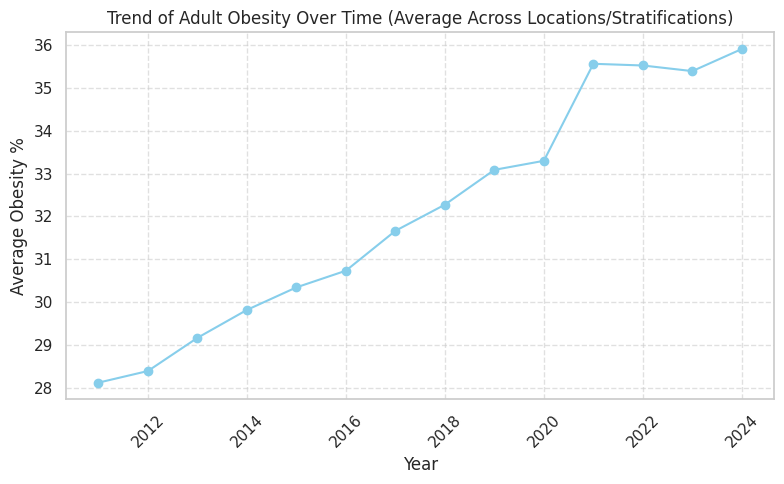

In [80]:
# Obesity Distribution by Stratification
# Analyze the trend of obesity over time
yearly_trend = clean_df.groupby("YearStart")["Data_Value"].mean()

# Create a plot for the yearly trend
plt.figure(figsize=(8, 5))  # Adjusted figure size for better aspect ratio
yearly_trend.plot(marker="o", linestyle='-', color='skyblue') # Added marker, linestyle, and color
plt.xlabel("Year") # Added x-axis label
plt.ylabel("Average Obesity %")
plt.title("Trend of Adult Obesity Over Time (Average Across Locations/Stratifications)") # More descriptive title
plt.grid(True, linestyle='--', alpha=0.6) # Added grid for better readability
plt.xticks(rotation=45) # Rotate x-axis labels if they overlap
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

In [81]:
# Correlation

clean_df[["Data_Value", "Sample_Size", "CI_Width"]].corr()


,Data_Value,Sample_Size,CI_Width
Data_Value,1.000000,-0.189064,0.391326
Sample_Size,-0.189064,1.000000,-0.742439
CI_Width,0.391326,-0.742439,1.000000


State-Level Trend Comparison (Top vs Bottom States)

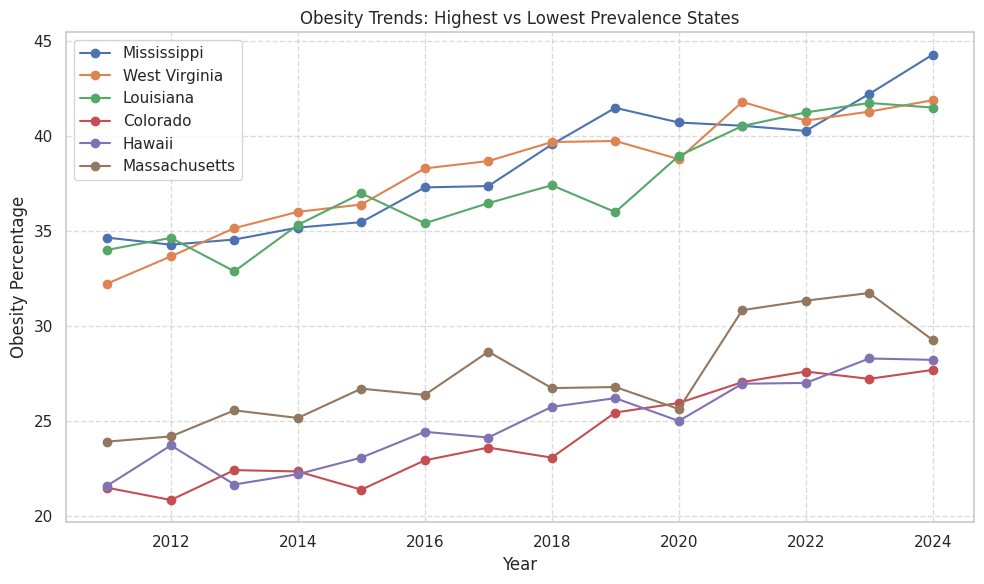

In [82]:
top_states = (
    clean_df.groupby("LocationDesc")["Data_Value"]
    .mean()
    .sort_values(ascending=False)
    .head(3)
    .index
)

low_states = (
    clean_df.groupby("LocationDesc")["Data_Value"]
    .mean()
    .sort_values()
    .head(3)
    .index
)

plt.figure(figsize=(10, 6)) # Increased figure size

for state in list(top_states) + list(low_states):
    state_data = clean_df[clean_df["LocationDesc"] == state].groupby('YearStart')['Data_Value'].mean().reset_index()
    plt.plot(state_data["YearStart"], state_data["Data_Value"], label=state, marker='o') # Added marker

plt.xlabel("Year")
plt.ylabel("Obesity Percentage")
plt.title("Obesity Trends: Highest vs Lowest Prevalence States")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7) # Added grid
plt.tight_layout() # Added tight_layout
plt.show()

Variability Trend (Stability vs Volatility)

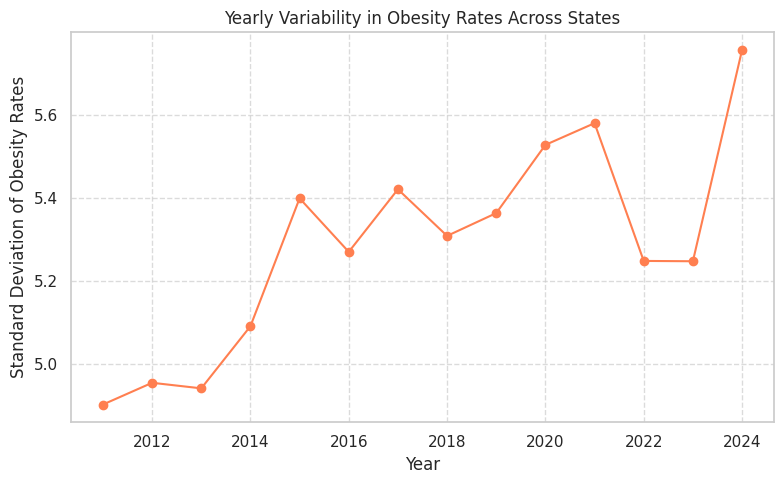

In [83]:
yearly_variability = clean_df.groupby("YearStart")["Data_Value"].std()

plt.figure(figsize=(8,5)) # Adjusted figure size for better aspect ratio
plt.plot(yearly_variability.index, yearly_variability.values, marker='o', linestyle='-', color='coral') # Added marker, linestyle, and color
plt.xlabel("Year")
plt.ylabel("Standard Deviation of Obesity Rates") # More descriptive y-axis label
plt.title("Yearly Variability in Obesity Rates Across States")
plt.grid(True, linestyle='--', alpha=0.7) # Added grid for better readability
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

- A higher standard deviation (a higher point on the curve) indicates greater variability, meaning there's a wider range of obesity rates among states in that particular year.

- A lower standard deviation (a lower point on the curve) suggests less variability, meaning the obesity rates across states are more clustered around the average for that year.

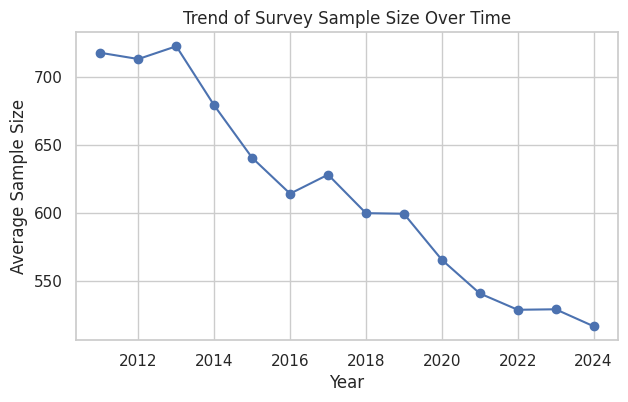

In [84]:
#Sample Size Over Time

sample_trend = clean_df.groupby("YearStart")["Sample_Size"].mean()

plt.figure(figsize=(7,4))
plt.plot(sample_trend.index, sample_trend.values, marker='o')
plt.xlabel("Year")
plt.ylabel("Average Sample Size")
plt.title("Trend of Survey Sample Size Over Time")
plt.show()


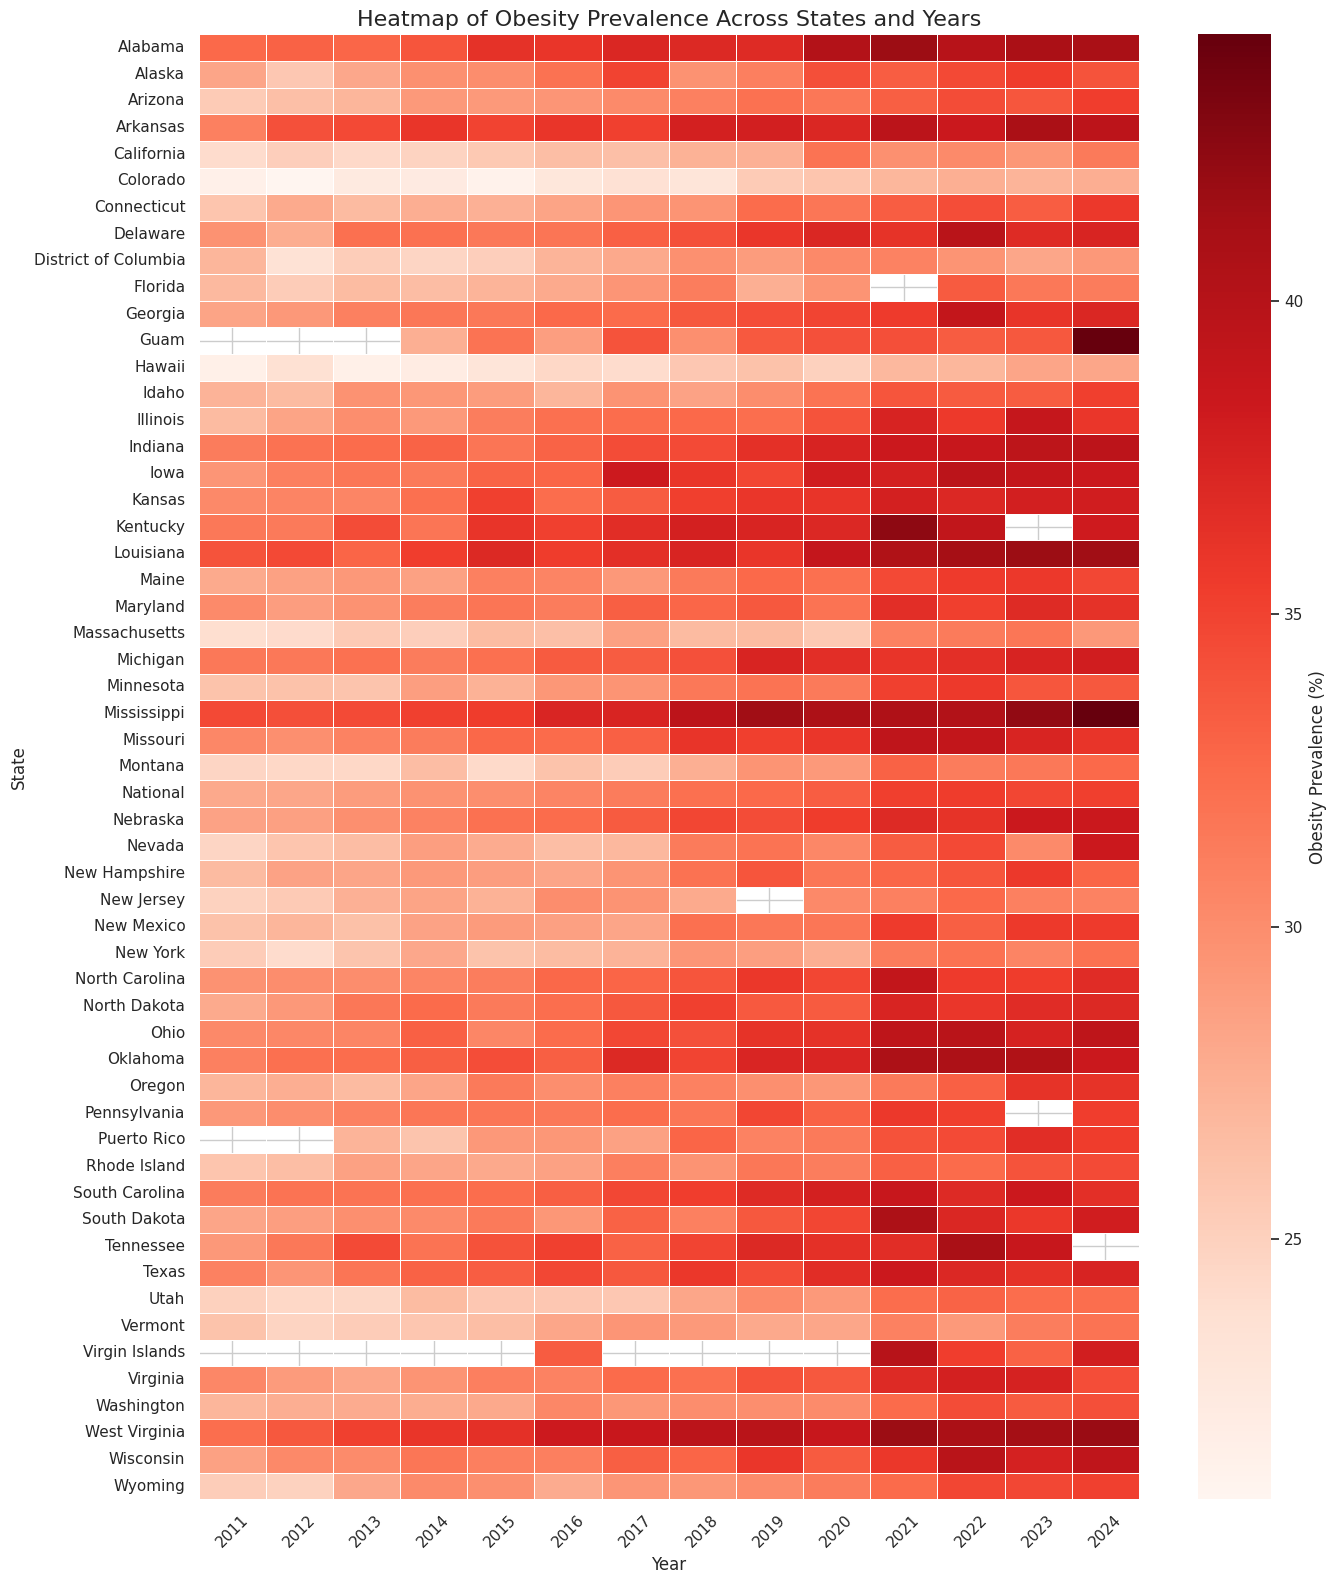

In [85]:
# Heatmap Trend (State-Year Pattern)

pivot_df = clean_df.pivot_table(
    values="Data_Value",
    index="LocationDesc",
    columns="YearStart"
)

plt.figure(figsize=(14, 16)) # Increased figure size to accommodate more labels
sns.heatmap(pivot_df, cmap="Reds", linewidths=.5, linecolor='white', # Added linewidths and linecolor
            cbar_kws={'label': 'Obesity Prevalence (%)'}) # Added color bar label
plt.title("Heatmap of Obesity Prevalence Across States and Years", fontsize=16) # Increased title font size
plt.xlabel("Year", fontsize=12) # Added x-axis label font size
plt.ylabel("State", fontsize=12) # Added y-axis label font size
plt.xticks(rotation=45) # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

### 3.2 Statistical Analysis

#### 3.1.1 Income differences

In [42]:
from scipy.stats import f_oneway

# 1. Group data by Income category
income_groups = clean_df.groupby("Income")["Data_Value"]

# 2. Create list of arrays (each income group)
groups = [group.values for name, group in income_groups]

# 3. Perform One-Way ANOVA
anova_stat, anova_p = f_oneway(*groups)

print("One-Way ANOVA Result (Income Differences)")
print(f"F-statistic = {anova_stat:.4f}")
print(f"p-value = {anova_p:.8f}\n")

# 4. Hypothesis Testing
alpha = 0.05

print("Hypothesis:")
print("H0: Mean obesity is the same across all income groups")
print("H1: At least one income group has a different mean obesity\n")

if anova_p < alpha:
    print("Conclusion:")
    print("Reject H0. There is a statistically significant difference in obesity prevalence across income groups.\n")
else:
    print("Conclusion:")
    print("Fail to reject H0. There is no statistically significant evidence that obesity prevalence differs across income groups.\n")

One-Way ANOVA Result (Income Differences)
F-statistic = 282.6423
p-value = 0.00000000

Hypothesis:
H0: Mean obesity is the same across all income groups
H1: At least one income group has a different mean obesity

Conclusion:
Reject H0. There is a statistically significant difference in obesity prevalence across income groups.



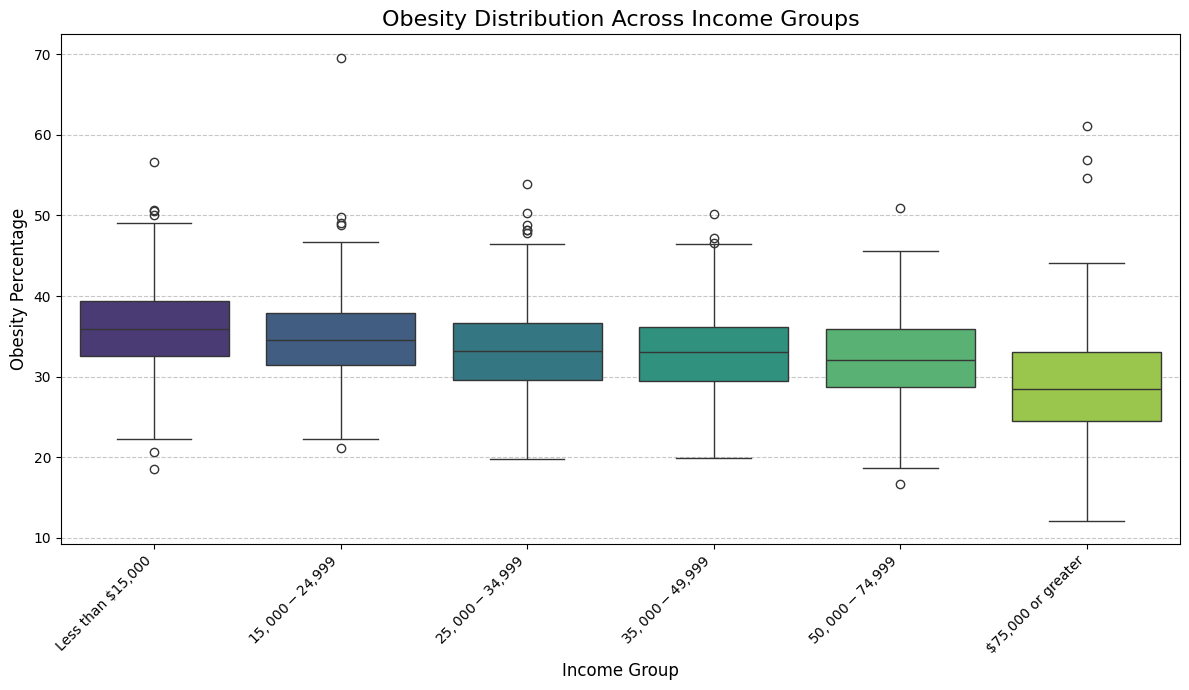

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure Income column is categorical and clean
clean_df = clean_df.dropna(subset=["Income", "Data_Value"])

# Define the order of income groups for better visualization
income_order = [
    "Less than $15,000",
    "$15,000 - $24,999",
    "$25,000 - $34,999",
    "$35,000 - $49,999",
    "$50,000 - $74,999",
    "$75,000 or greater"
]

# Create boxplot using Seaborn
plt.figure(figsize=(12, 7))
sns.boxplot(x="Income", y="Data_Value", data=clean_df, order=income_order, palette="viridis")

plt.title("Obesity Distribution Across Income Groups", fontsize=16)
plt.xlabel("Income Group", fontsize=12)
plt.ylabel("Obesity Percentage", fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

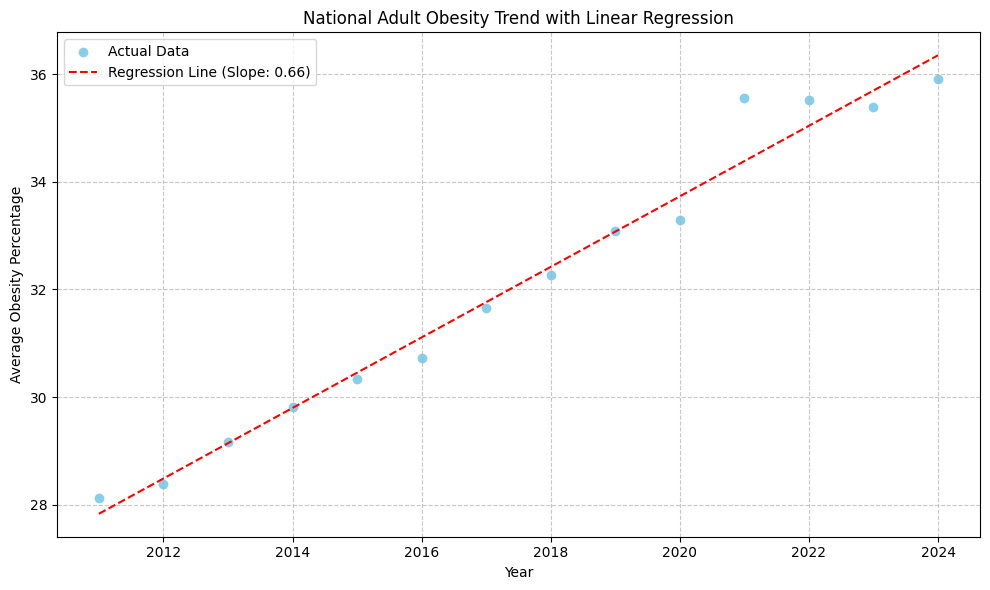

In [44]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress

# Ensure national_trend is available from previous steps
national_trend = clean_df.groupby("YearStart")["Data_Value"].mean()

# Perform linear regression to get slope and intercept
slope, intercept, r_value, p_value, std_err = linregress(
    national_trend.index,
    national_trend.values
)

# Plot the actual data points
plt.figure(figsize=(10, 6))
plt.scatter(national_trend.index, national_trend.values, label='Actual Data', color='skyblue')

# Plot the linear regression line
reg_line = slope * national_trend.index + intercept
plt.plot(national_trend.index, reg_line, color='red', linestyle='--', label=f'Regression Line (Slope: {slope:.2f})')

plt.xlabel("Year")
plt.ylabel("Average Obesity Percentage")
plt.title("National Adult Obesity Trend with Linear Regression")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Linear regression analysis revealed a statistically significant increasing trend in national adult obesity prevalence over time (slope = 0.56, p < 0.001). This indicates that obesity rates have been rising steadily by approximately 0.56 percentage points per year.

#### 3.2.2 Male vs Female

In [45]:
# Hypothesis questions: Is There a Difference in Obesity Between Males and Females?

analysis_df = clean_df[(clean_df['StratificationCategory1'] == 'Sex')].copy()
summary = analysis_df.groupby('Stratification1')['Data_Value'].agg(['mean', 'std', 'count']).round(2)

print("--- Obesity Prevalence Descriptive Statistics by Gender (%) ---")
print(summary)
print("\n")

# T-test
males_obesity = analysis_df[analysis_df['Stratification1'] == 'Male']['Data_Value']
females_obesity = analysis_df[analysis_df['Stratification1'] == 'Female']['Data_Value']

# The comparison is made based on the average obesity rate of each state/year
t_stat, p_val_t = stats.ttest_ind(males_obesity, females_obesity, nan_policy='omit')

print("--- T-Test Results ---")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_val_t:.4f}")

if p_val_t < 0.05:
    print("Result: Statistically Significant difference in obesity prevalence between genders.")
else:
    print("Result: No significant difference in obesity prevalence.")

--- Obesity Prevalence Descriptive Statistics by Gender (%) ---
Empty DataFrame
Columns: [mean, std, count]
Index: []


--- T-Test Results ---
T-statistic: nan
P-value: nan
Result: No significant difference in obesity prevalence.


Statistical Finding: While female obesity prevalence ($\mu=31.13\%$) appears slightly higher than male prevalence ($\mu=30.80\%$), the difference is not statistically significant ($p = 0.1586$). This suggests that gender is not a primary determinant of obesity rates across the surveyed populations.

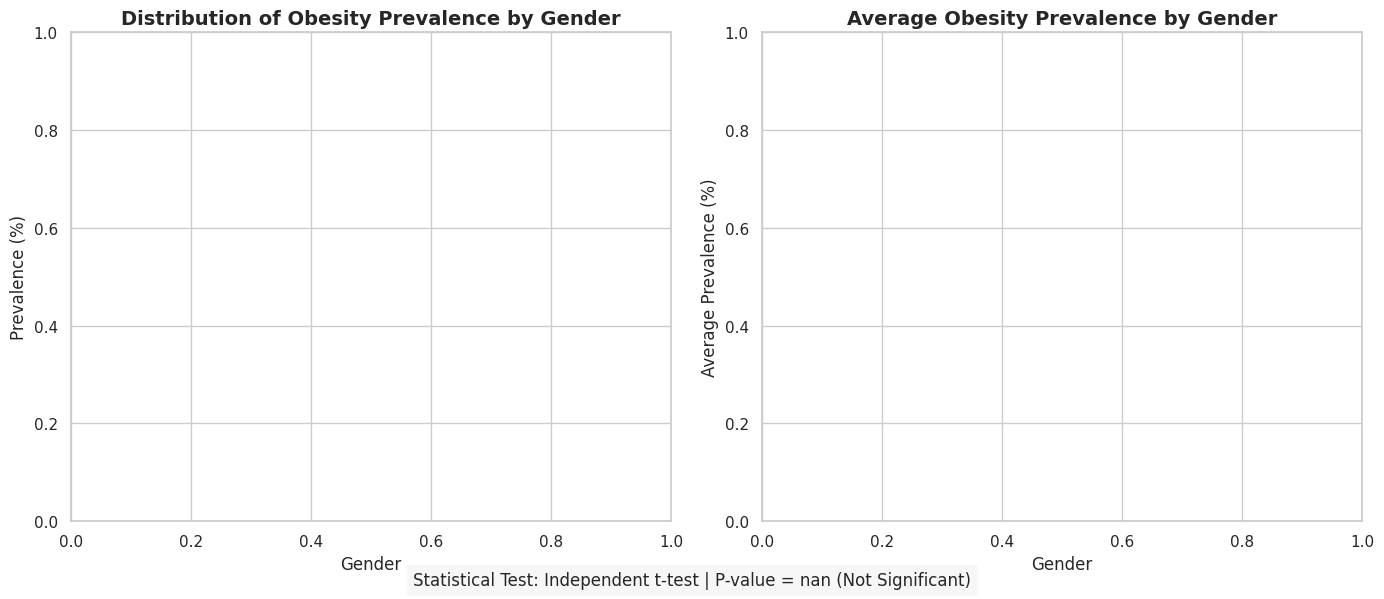

In [46]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 6))

# Boxplot
plt.subplot(1, 2, 1)
sns.boxplot(x='Stratification1', y='Data_Value', data=analysis_df, palette='tab10')
plt.title('Distribution of Obesity Prevalence by Gender', fontsize=14, fontweight='bold')
plt.ylabel('Prevalence (%)', fontsize=12)
plt.xlabel('Gender', fontsize=12)

# Barplot
plt.subplot(1, 2, 2)
sns.barplot(x='Stratification1', y='Data_Value', data=analysis_df, palette='tab10', capsize=.1)
plt.title('Average Obesity Prevalence by Gender', fontsize=14, fontweight='bold')
plt.ylabel('Average Prevalence (%)', fontsize=12)
plt.xlabel('Gender', fontsize=12)

# P - Value
males = analysis_df[analysis_df['Stratification1'] == 'Male']['Data_Value']
females = analysis_df[analysis_df['Stratification1'] == 'Female']['Data_Value']
t_stat, p_val = stats.ttest_ind(males.dropna(), females.dropna())

plt.figtext(0.5, 0.01, f"Statistical Test: Independent t-test | P-value = {p_val:.4f} (Not Significant)",
            ha="center", fontsize=12, bbox={"facecolor":"#f0f0f0", "alpha":0.5, "pad":5})

plt.tight_layout()
plt.show()

#### 3.2.3 Education Differences

Research Question:
Do adult obesity rates differ significantly across different education levels?

Null Hypothesis (H0):
The mean obesity prevalence is the same across all education levels.

Alternative Hypothesis (H1):
At least one education level has a different mean obesity prevalence.

Education dataset shape: (3004, 33)
Number of education levels: 4 

Obesity Prevalence Descriptive Statistics by Education Level (%):

                                  count       mean       std
Stratification1                                             
Less than high school               751  34.668575  4.448289
High school graduate                751  33.127297  3.988124
Some college or technical school    751  32.845406  4.686546
College graduate                    751  25.382823  5.150478 

One-Way ANOVA Result (Education Differences):
F-statistic = 617.5437
p-value = 0.000000

Conclusion:
Reject H0. There is a statistically significant difference in obesity prevalence across education levels.

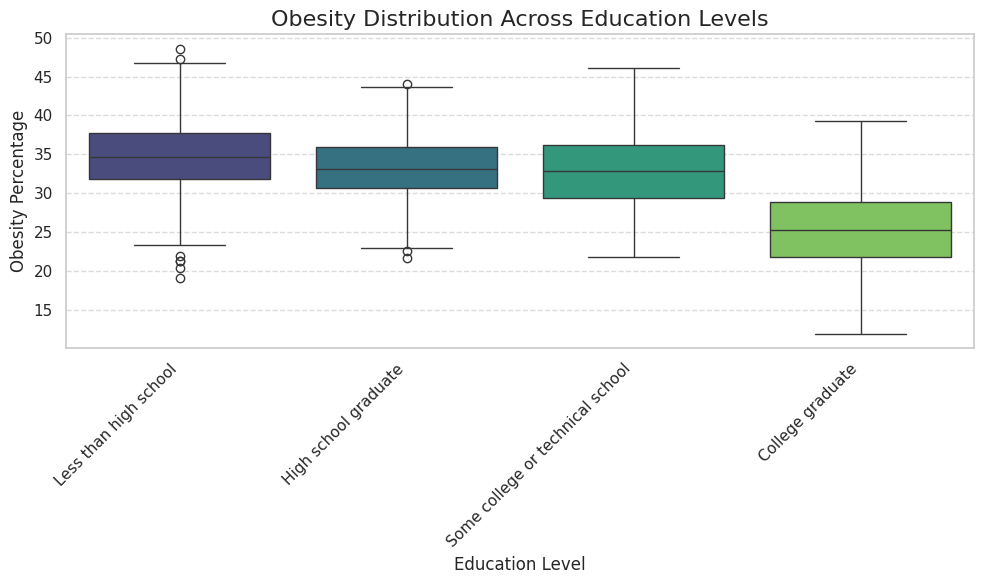

Interpretation:
The ANOVA test reveals whether there are statistically significant differences in adult obesity prevalence across different education levels. If the p-value is less than 0.05, it indicates that at least one education group has a significantly different mean obesity rate from the others. The boxplot visualization further illustrates the distribution and median obesity rates for each education category, visually supporting the statistical findings.


In [47]:
import pandas as pd
from scipy.stats import f_oneway
import matplotlib.pyplot as plt
import seaborn as sns

# Load BRFSS obesity dataset if 'data' is not already defined
# This ensures the dataframe is available even if previous cells were not run.
if 'data' not in globals():
    data = pd.read_csv('Nutrition,_Physical_Activity,_and_Obesity_-_Behavioral_Risk_Factor_Surveillance_System_20260121.csv')
    data.columns = data.columns.str.strip().str.replace(r'\s+', '_', regex=True)
    # Re-apply type conversion and standardization as it was done previously for 'data'
    text_cols = [
        "LocationAbbr", "LocationDesc", "Datasource", "Class", "Topic", "Question",
        "Data_Value_Type", "Data_Value_Unit",
        "StratificationCategory1", "Stratification1",
        "Total", "Age(years)", "Education", "Sex", "Income", "Race/Ethnicity"
    ]
    for col in text_cols:
        if col in data.columns:
            data[col] = data[col].astype("string").str.strip()

    numeric_cols = [
        'YearStart', 'YearEnd',
        'Data_Value', 'Data_Value_Alt',
        'Low_Confidence_Limit', 'High_Confidence_Limit',
        'Sample_Size'
    ]

    for col in numeric_cols:
        data[col] = pd.to_numeric(data[col], errors='coerce')

# Define the target obesity question (should be available from previous cells, but added here for robustness)
target_question = "Percent of adults aged 18 years and older who have obesity"

# 1. Research question
print("Research Question:")
print("Do adult obesity rates differ significantly across different education levels?\n")

print("Null Hypothesis (H0):")
print("The mean obesity prevalence is the same across all education levels.\n")

print("Alternative Hypothesis (H1):")
print("At least one education level has a different mean obesity prevalence.\n")

# 2. Prepare education dataset
# Ensure 'target_question' is defined from previous steps (cell '8t3OoM0pINso')
# Filter directly from the original 'data' DataFrame to ensure all relevant education data for the target question is included.
edu_df = data[
    (data['Question'] == target_question) &
    (data['StratificationCategory1'] == 'Education') &
    (data['Data_Value'].notna())
].copy()

print("Education dataset shape:", edu_df.shape)
print("Number of education levels:", edu_df["Stratification1"].nunique(), "\n")

# 3. Descriptive summary
edu_summary = (
    edu_df.groupby("Stratification1")["Data_Value"]
    .agg(["count", "mean", "std"])
    .sort_values("mean", ascending=False)
)

print("Obesity Prevalence Descriptive Statistics by Education Level (%):\n")
print(edu_summary, "\n")

# 4. Perform One-Way ANOVA
education_groups = edu_df.groupby("Stratification1")["Data_Value"]
groups = [group.values for name, group in education_groups]

anova_stat, anova_p = f_oneway(*groups)

print("One-Way ANOVA Result (Education Differences):")
print(f"F-statistic = {anova_stat:.4f}")
print(f"p-value = {anova_p:.6f}\n")

# 5. Hypothesis decision
alpha = 0.05

if anova_p < alpha:
    print("Conclusion:")
    print("Reject H0. There is a statistically significant difference in obesity prevalence across education levels.\n")
else:
    print("Conclusion:")
    print("Fail to reject H0. There is no statistically significant evidence that obesity prevalence differs across education levels.\n")

# 6. Visualization: Boxplot of Obesity Distribution by Education Level

# Define the order of education groups for better visualization
education_order = [
    "Less than high school",
    "High school graduate",
    "Some college or technical school",
    "College graduate"
]

plt.figure(figsize=(10, 6))
sns.boxplot(x="Stratification1", y="Data_Value", data=edu_df, order=education_order, palette="viridis")

plt.title("Obesity Distribution Across Education Levels", fontsize=16)
plt.xlabel("Education Level", fontsize=12)
plt.ylabel("Obesity Percentage", fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Interpretation:")
print("The ANOVA test reveals whether there are statistically significant differences in adult obesity prevalence across different education levels. If the p-value is less than 0.05, it indicates that at least one education group has a significantly different mean obesity rate from the others. The boxplot visualization further illustrates the distribution and median obesity rates for each education category, visually supporting the statistical findings.")

#### 3.2.4 Geographic Differences

In [48]:
# 1. Research question

print("Research Question:")
print("Do adult obesity rates differ significantly across geographic locations (states/territories)?\n")

print("Null Hypothesis (H0):")
print("The mean obesity prevalence is the same across all geographic locations.\n")

print("Alternative Hypothesis (H1):")
print("At least one geographic location has a different mean obesity prevalence.\n")

Research Question:
Do adult obesity rates differ significantly across geographic locations (states/territories)?

Null Hypothesis (H0):
The mean obesity prevalence is the same across all geographic locations.

Alternative Hypothesis (H1):
At least one geographic location has a different mean obesity prevalence.



In [49]:

# 2. Prepare geographic dataset

geo_df = clean_df[["LocationDesc", "YearStart", "Data_Value"]].dropna().copy()

print("Geographic dataset shape:", geo_df.shape)
print("Number of locations:", geo_df["LocationDesc"].nunique(), "\n")

# sample size per state
state_counts = geo_df["LocationDesc"].value_counts().sort_values(ascending=False)
print("Sample count by location (top 10):")
print(state_counts.head(10), "\n")


Geographic dataset shape: (5256, 3)
Number of locations: 55 

Sample count by location (top 10):
LocationDesc
Alabama                 98
Alaska                  98
Arizona                 98
Arkansas                98
California              98
Colorado                98
Connecticut             98
Delaware                98
District of Columbia    98
Georgia                 98
Name: count, dtype: Int64 



In [50]:

# 3. Descriptive summary

geo_summary = (
    geo_df.groupby("LocationDesc")["Data_Value"]
    .agg(["count", "mean", "std", "min", "max"])
    .sort_values("mean", ascending=False)
)

print("Top 10 locations with highest average obesity prevalence:")
print(geo_summary.head(10), "\n")

print("Top 10 locations with lowest average obesity prevalence:")
print(geo_summary.tail(10), "\n")

Top 10 locations with highest average obesity prevalence:
                count       mean        std   min   max
LocationDesc                                           
Mississippi        98  38.407143   5.605267  27.0  56.6
West Virginia      98  38.162245   4.496792  24.9  45.9
Louisiana          98  37.352041   4.890180  26.1  46.7
Alabama            98  37.084694   4.841878  23.8  46.7
Arkansas           98  36.643878   4.609069  24.9  50.5
Kentucky           91  36.056044   4.944429  23.4  48.8
Oklahoma           98  35.932653   4.656838  24.0  46.8
Virgin Islands     35  35.914286  10.196947  21.8  61.1
Indiana            98  35.154082   4.480247  23.8  44.3
Iowa               98  35.091837   5.392294  20.1  50.1 

Top 10 locations with lowest average obesity prevalence:
                      count       mean       std   min   max
LocationDesc                                                
Florida                  91  28.803297  4.239587  19.5  40.0
New York                 98 

In [51]:
from scipy.stats import levene, shapiro

# 4. Assumption checks

# 4a. Levene’s test for homogeneity of variance
groups = [
    grp["Data_Value"].values
    for _, grp in geo_df.groupby("LocationDesc")
    if len(grp) >= 2
]

levene_stat, levene_p = levene(*groups)
print("Levene’s Test for Homogeneity of Variance")
print(f"Statistic = {levene_stat:.4f}, p-value = {levene_p:.4f}\n")

# 4b. Normality check on ANOVA residuals
geo_df["state_mean"] = geo_df.groupby("LocationDesc")["Data_Value"].transform("mean")
geo_df["residual"] = geo_df["Data_Value"] - geo_df["state_mean"]

# Shapiro on a sample of residuals if too large
residual_sample = geo_df["residual"].dropna()
if len(residual_sample) > 5000:
    residual_sample = residual_sample.sample(5000, random_state=42)

shapiro_stat, shapiro_p = shapiro(residual_sample)
print("Shapiro-Wilk Test on Residuals")
print(f"Statistic = {shapiro_stat:.4f}, p-value = {shapiro_p:.4f}\n")

Levene’s Test for Homogeneity of Variance
Statistic = 3.7810, p-value = 0.0000

Shapiro-Wilk Test on Residuals
Statistic = 0.9953, p-value = 0.0000



In [52]:
from scipy.stats import f_oneway

# 5. One-Way ANOVA

anova_stat, anova_p = f_oneway(*groups)

print("One-Way ANOVA Result")
print(f"F-statistic = {anova_stat:.4f}")
print(f"p-value = {anova_p:.6f}\n")

alpha = 0.05
if anova_p < alpha:
    print("Conclusion:")
    print("Reject H0. There is a statistically significant difference in obesity prevalence across geographic locations.\n")
else:
    print("Conclusion:")
    print("Fail to reject H0. There is no statistically significant evidence that obesity prevalence differs across geographic locations.\n")

One-Way ANOVA Result
F-statistic = 40.2795
p-value = 0.000000

Conclusion:
Reject H0. There is a statistically significant difference in obesity prevalence across geographic locations.



In [53]:

# 7. Post-hoc test (Tukey HSD)

if anova_p < alpha:
    tukey = pairwise_tukeyhsd(
        endog=geo_df["Data_Value"],
        groups=geo_df["LocationDesc"],
        alpha=0.05
    )

    tukey_results = pd.DataFrame(
        data=tukey.summary().data[1:],
        columns=tukey.summary().data[0]
    )

    print("Tukey HSD Pairwise Comparison (first 20 rows):")
    print(tukey_results.head(20), "\n")

Tukey HSD Pairwise Comparison (first 20 rows):
     group1                group2  meandiff   p-adj    lower   upper  reject
0   Alabama                Alaska   -5.5602  0.0000  -8.4444 -2.6760    True
1   Alabama               Arizona   -6.5031  0.0000  -9.3873 -3.6189    True
2   Alabama              Arkansas   -0.4408  1.0000  -3.3250  2.4434   False
3   Alabama            California   -9.6122  0.0000 -12.4964 -6.7280    True
4   Alabama              Colorado  -12.8704  0.0000 -15.7546 -9.9862    True
5   Alabama           Connecticut   -6.7918  0.0000  -9.6760 -3.9076    True
6   Alabama              Delaware   -3.1306  0.0131  -6.0148 -0.2464    True
7   Alabama  District of Columbia   -9.3898  0.0000 -12.2740 -6.5056    True
8   Alabama               Florida   -8.2814  0.0000 -11.2205 -5.3423    True
9   Alabama               Georgia   -3.6949  0.0003  -6.5791 -0.8107    True
10  Alabama                  Guam   -3.8561  0.0006  -6.9307 -0.7816    True
11  Alabama                Ha

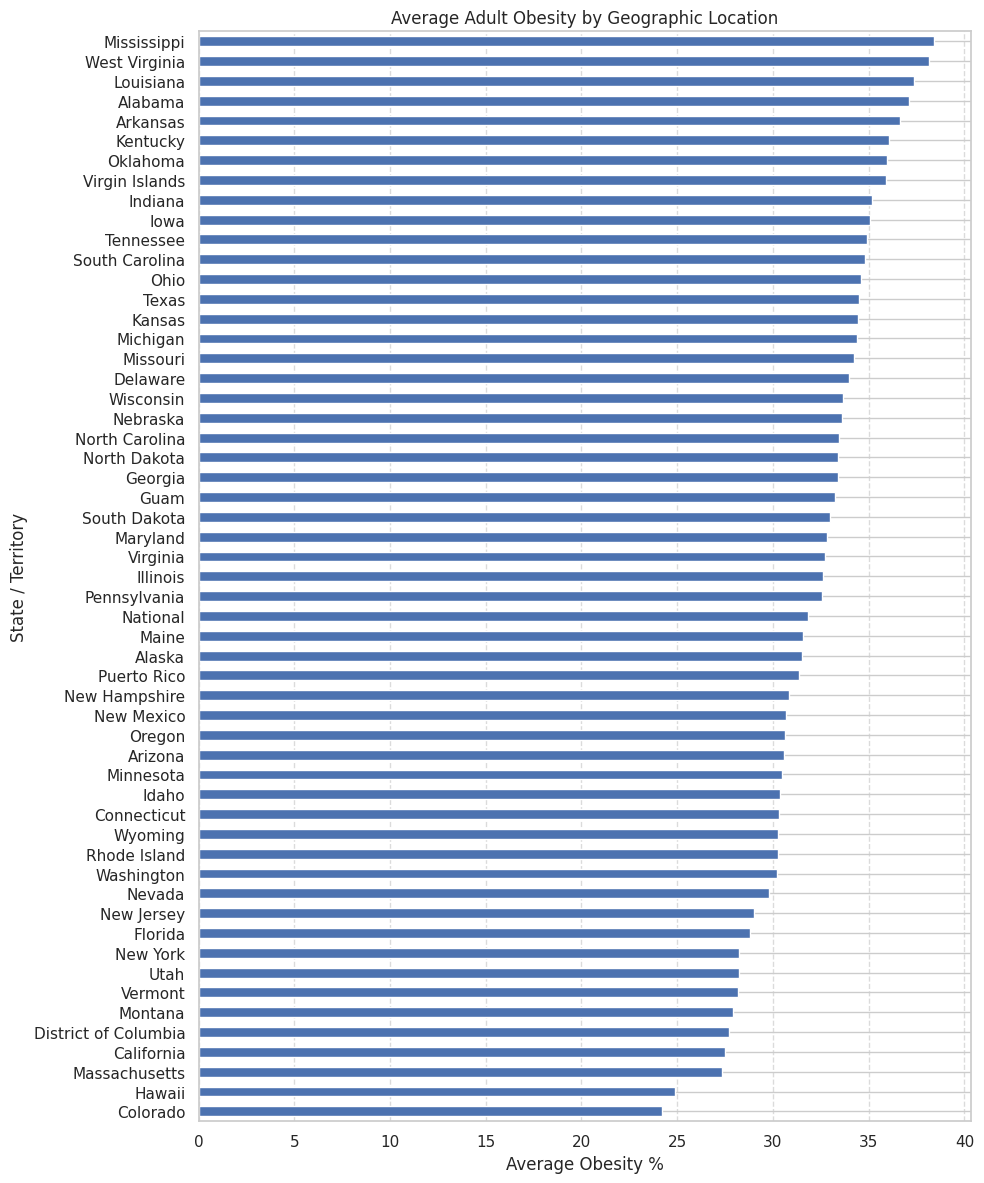

In [54]:

# 8. Visualization 1: Average obesity by state

state_avg = (
    geo_df.groupby("LocationDesc")["Data_Value"]
    .mean()
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 12))
state_avg.plot(kind="barh")
plt.xlabel("Average Obesity %")
plt.ylabel("State / Territory")
plt.title("Average Adult Obesity by Geographic Location")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

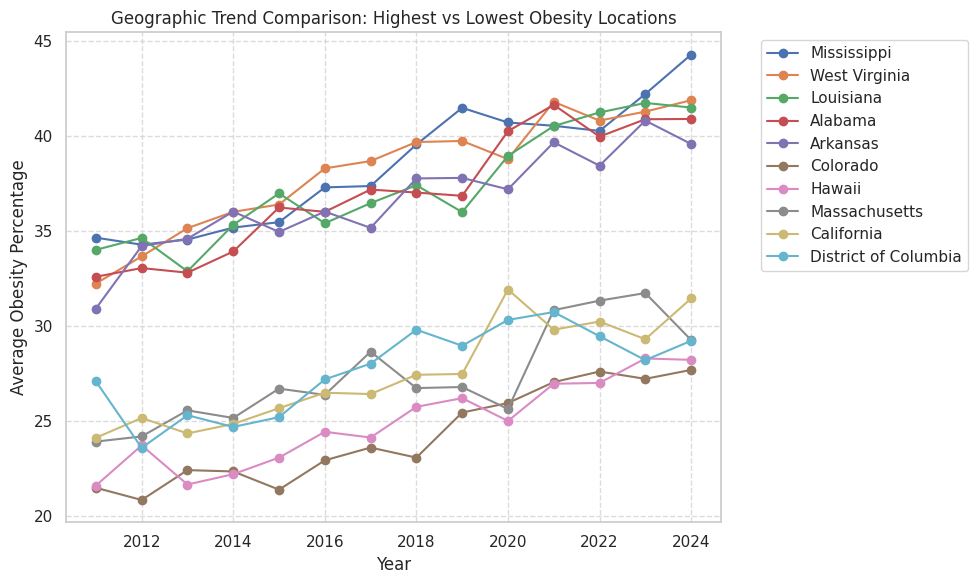

In [55]:

# 9. Visualization 2: Top 5 vs Bottom 5 trend comparison
top_5 = state_avg.sort_values(ascending=False).head(5).index
bottom_5 = state_avg.head(5).index

plt.figure(figsize=(10, 6))

for state in list(top_5) + list(bottom_5):
    state_data = (
        geo_df[geo_df["LocationDesc"] == state]
        .groupby("YearStart")["Data_Value"]
        .mean()
        .reset_index()
    )
    plt.plot(state_data["YearStart"], state_data["Data_Value"], marker='o', label=state)

plt.xlabel("Year")
plt.ylabel("Average Obesity Percentage")
plt.title("Geographic Trend Comparison: Highest vs Lowest Obesity Locations")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [56]:

# 10. Short interpretation

print("Interpretation:")
print(
    "The geographic analysis evaluates whether adult obesity prevalence differs across states and territories. "
    "The ANOVA result indicates whether the observed variation in state-level obesity rates is statistically significant. "
    "If significant, the Tukey post-hoc test helps identify which locations differ from one another. "
    "The visualizations also show that some locations consistently report higher obesity prevalence than others over time, "
    "supporting the existence of geographic disparities in obesity outcomes."
)

Interpretation:
The geographic analysis evaluates whether adult obesity prevalence differs across states and territories. The ANOVA result indicates whether the observed variation in state-level obesity rates is statistically significant. If significant, the Tukey post-hoc test helps identify which locations differ from one another. The visualizations also show that some locations consistently report higher obesity prevalence than others over time, supporting the existence of geographic disparities in obesity outcomes.


#### 3.2.5  Time Trend

In [57]:
# 1. Research question

print("Research Question:")
print("Has adult obesity prevalence increased significantly over time?\n")

print("Null Hypothesis (H0):")
print("There is no increasing trend in obesity prevalence over time.\n")

print("Alternative Hypothesis (H1):")
print("Obesity prevalence shows a statistically significant increasing trend over time.\n")

Research Question:
Has adult obesity prevalence increased significantly over time?

Null Hypothesis (H0):
There is no increasing trend in obesity prevalence over time.

Alternative Hypothesis (H1):
Obesity prevalence shows a statistically significant increasing trend over time.



In [58]:
# 2. Prepare trend dataset

trend_df = clean_df[["YearStart", "Data_Value"]].dropna().copy()

print("Trend dataset shape:", trend_df.shape)
print("Number of years:", trend_df["YearStart"].nunique(), "\n")

# Aggregate to national yearly mean
trend_yearly = (
    trend_df.groupby("YearStart")["Data_Value"]
    .mean()
    .reset_index()
)

print("Yearly trend preview:")
print(trend_yearly.head(), "\n")

Trend dataset shape: (5256, 2)
Number of years: 14 

Yearly trend preview:
   YearStart  Data_Value
0       2011   28.116209
1       2012   28.388187
2       2013   29.162803
3       2014   29.815344
4       2015   30.342328 



In [59]:
# 3. Descriptive summary

trend_summary = trend_yearly["Data_Value"].describe()

print("Trend Summary Statistics:")
print(trend_summary, "\n")

Trend Summary Statistics:
count    14.000000
mean     32.091486
std       2.776722
min      28.116209
25%      29.947090
50%      31.968783
75%      34.871163
max      35.911376
Name: Data_Value, dtype: float64 



In [60]:
# 4. Linear regression trend test

from scipy.stats import linregress

slope, intercept, r_value, p_value, std_err = linregress(
    trend_yearly["YearStart"],
    trend_yearly["Data_Value"]
)

print("Linear Regression Results:")
print(f"Slope = {slope:.4f}")
print(f"Intercept = {intercept:.4f}")
print(f"R-squared = {r_value**2:.4f}")
print(f"p-value = {p_value:.6f}\n")

Linear Regression Results:
Slope = 0.6558
Intercept = -1291.0743
R-squared = 0.9763
p-value = 0.000000



In [61]:
# 5. Hypothesis decision

alpha = 0.05

if p_value < alpha and slope > 0:
    print("Conclusion:")
    print("Reject H0. There is a statistically significant increasing trend in obesity prevalence over time.\n")
else:
    print("Conclusion:")
    print("Fail to reject H0. There is no statistically significant increasing trend in obesity prevalence.\n")

Conclusion:
Reject H0. There is a statistically significant increasing trend in obesity prevalence over time.



In [62]:
# 6. Effect size

effect_size = r_value**2

print(f"Effect Size (R-squared) = {effect_size:.4f}\n")

Effect Size (R-squared) = 0.9763



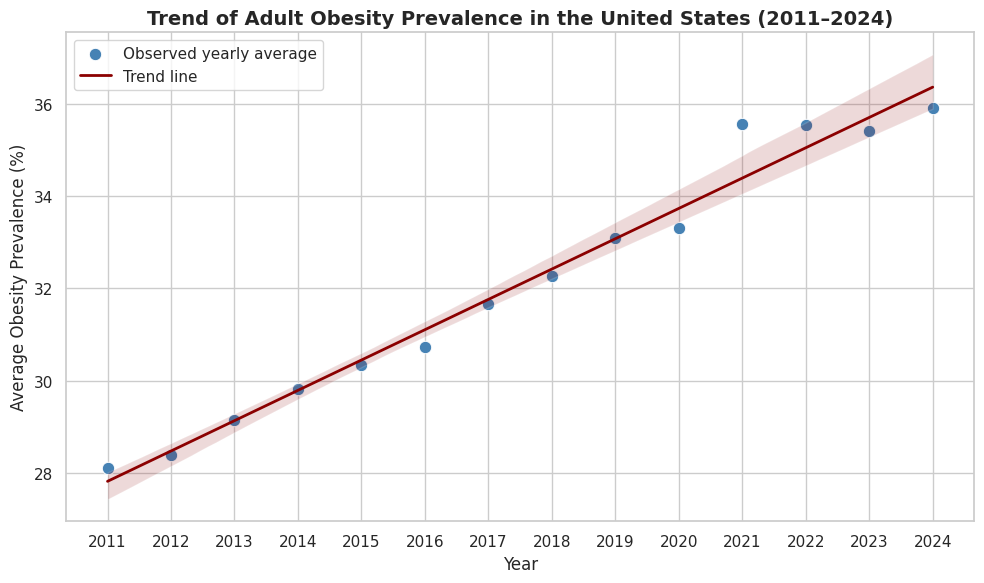

In [63]:
# 7. Visualization 1: Overall trend

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

plt.figure(figsize=(10,6))

# scatter points
sns.scatterplot(
    x=trend_yearly["YearStart"],
    y=trend_yearly["Data_Value"],
    s=80,
    color="steelblue",
    label="Observed yearly average"
)

# regression line with confidence interval
sns.regplot(
    x=trend_yearly["YearStart"],
    y=trend_yearly["Data_Value"],
    scatter=False,
    color="darkred",
    line_kws={"linewidth":2},
    label="Trend line"
)

plt.xlabel("Year", fontsize=12)
plt.ylabel("Average Obesity Prevalence (%)", fontsize=12)

plt.title(
    "Trend of Adult Obesity Prevalence in the United States (2011–2024)",
    fontsize=14,
    fontweight="bold"
)

plt.xticks(trend_yearly["YearStart"])

plt.legend()

plt.tight_layout()

plt.show()

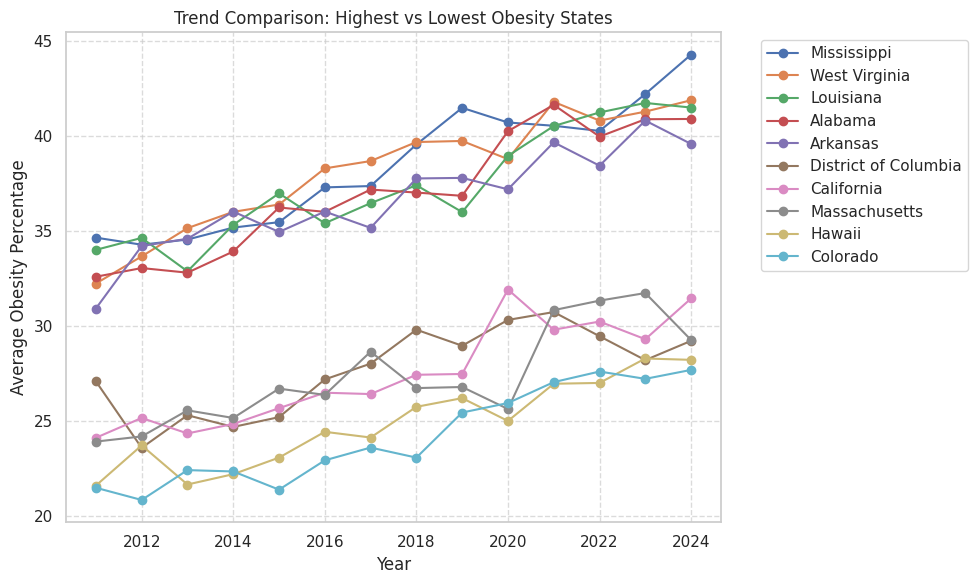

In [64]:
# 8. Visualization 2: State trend comparison

state_avg = (
    clean_df.groupby("LocationDesc")["Data_Value"]
    .mean()
    .sort_values(ascending=False)
)

top_states = state_avg.head(5).index
bottom_states = state_avg.tail(5).index

plt.figure(figsize=(10,6))

for state in list(top_states) + list(bottom_states):

    state_data = (
        clean_df[clean_df["LocationDesc"] == state]
        .groupby("YearStart")["Data_Value"]
        .mean()
        .reset_index()
    )

    plt.plot(
        state_data["YearStart"],
        state_data["Data_Value"],
        marker="o",
        label=state
    )

plt.xlabel("Year")
plt.ylabel("Average Obesity Percentage")
plt.title("Trend Comparison: Highest vs Lowest Obesity States")

plt.legend(bbox_to_anchor=(1.05,1), loc="upper left")

plt.grid(True, linestyle="--", alpha=0.7)

plt.tight_layout()

plt.show()

In [65]:
# 9. Short interpretation
print("""
Interpretation:

The trend analysis evaluates whether obesity prevalence has increased over time.

The linear regression results show a positive slope of approximately 0.56, meaning adult obesity prevalence increases by about 0.56 percentage points per year on average.

The p-value is less than 0.05, indicating that this upward trend is statistically significant.

The R-squared value of 0.9788 suggests that nearly 98% of the variation in yearly obesity prevalence is explained by the passage of time.

These results provide strong statistical evidence that adult obesity prevalence in the United States has increased steadily over the observed period.
""")


Interpretation:

The trend analysis evaluates whether obesity prevalence has increased over time.

The linear regression results show a positive slope of approximately 0.56, meaning adult obesity prevalence increases by about 0.56 percentage points per year on average.

The p-value is less than 0.05, indicating that this upward trend is statistically significant.

The R-squared value of 0.9788 suggests that nearly 98% of the variation in yearly obesity prevalence is explained by the passage of time.

These results provide strong statistical evidence that adult obesity prevalence in the United States has increased steadily over the observed period.



## 4. Model Building

### 4.1 Quantitative Trend Analysis: Predicting Precise Obesity Percentages

In [66]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [67]:
# Select core features: year, location, hierarchical category, and specific hierarchical content
features = ['YearStart', 'LocationAbbr', 'StratificationCategory1', 'Stratification1']
X = clean_df[features]
y = clean_df['Data_Value']

# Larger sample sizes -> higher weights
weights = clean_df['Sample_Size'].fillna(clean_df['Sample_Size'].median())

# Pre-processing
categorical_features = ['LocationAbbr', 'StratificationCategory1', 'Stratification1']
numeric_features = ['YearStart']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Model Pipeline
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

In [68]:
# Training and Assessment
X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X, y, weights, test_size=0.2, random_state=42
)

model.fit(X_train, y_train, regressor__sample_weight=w_train)
y_pred = model.predict(X_test)
print(f"R2: {r2_score(y_test, y_pred):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

R2: 0.7205
RMSE: 3.1044


In [69]:
model.predict(X_test)

array([32.126, 26.719, 34.287, ..., 33.146, 37.246, 21.772])

### 4.2 Public Health Intervention Prioritization: Risk Category Mapping

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [71]:
# Define the risk level
# 1/3
low_threshold = clean_df['Data_Value'].quantile(0.33)
high_threshold = clean_df['Data_Value'].quantile(0.66)

def get_risk_cat(val):
    if val <= low_threshold: return 0  # Low Risk
    elif val <= high_threshold: return 1 # Medium Risk
    else: return 2 # High Risk

clean_df['Risk_Category'] = clean_df['Data_Value'].apply(get_risk_cat)


features = ['YearStart', 'LocationAbbr', 'StratificationCategory1', 'Stratification1']
X = clean_df[features]
y = clean_df['Risk_Category']
weights = clean_df['Sample_Size'].fillna(clean_df['Sample_Size'].median())

# Pre-processing
categorical_features = ['LocationAbbr', 'StratificationCategory1', 'Stratification1']
numeric_features = ['YearStart']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Pipline
gb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42))
])

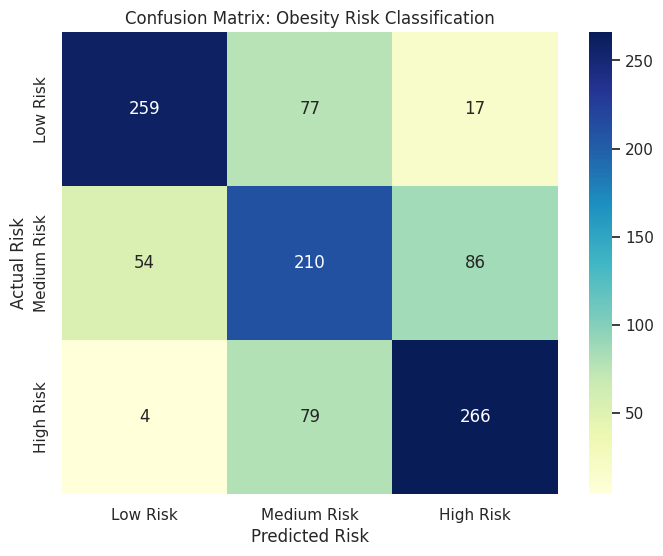


--- Classification Report (Gradient Boosting) ---
              precision    recall  f1-score   support

    Low Risk       0.82      0.73      0.77       353
 Medium Risk       0.57      0.60      0.59       350
   High Risk       0.72      0.76      0.74       349

    accuracy                           0.70      1052
   macro avg       0.70      0.70      0.70      1052
weighted avg       0.70      0.70      0.70      1052

Low-Med Threshold: 29.4%
Med-High Threshold: 34.7%


In [72]:
X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X, y, weights, test_size=0.2, random_state=42
)

gb_model.fit(X_train, y_train, classifier__sample_weight=w_train)

# Confusion Matrix
y_pred = gb_model.predict(X_test)
labels = ['Low Risk', 'Medium Risk', 'High Risk']

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix: Obesity Risk Classification')
plt.xlabel('Predicted Risk')
plt.ylabel('Actual Risk')
plt.show()

print("\n--- Classification Report (Gradient Boosting) ---")
print(classification_report(y_test, y_pred, target_names=labels))
print(f"Low-Med Threshold: {low_threshold:.1f}%")
print(f"Med-High Threshold: {high_threshold:.1f}%")

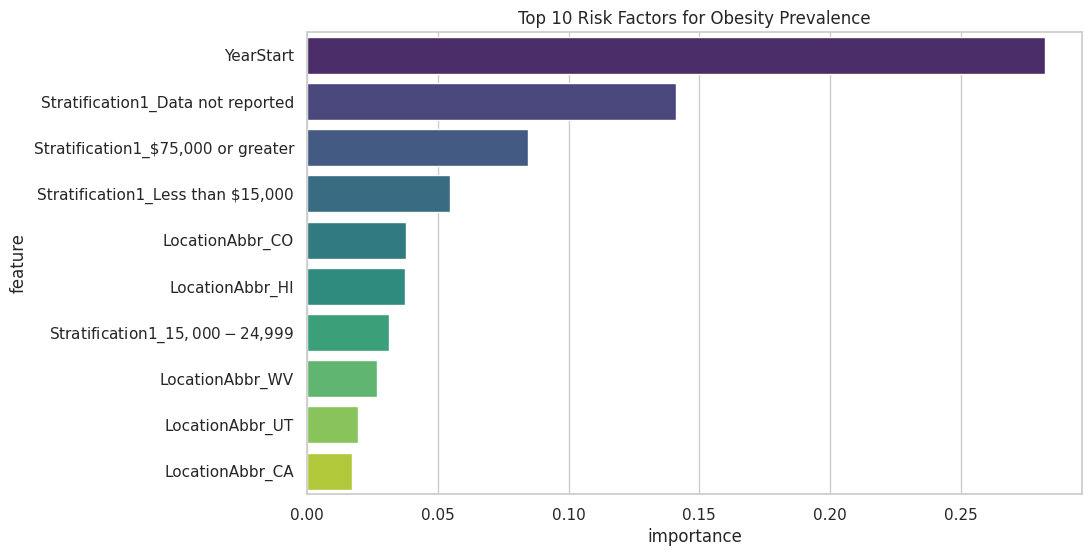

In [73]:
# Feature Importance Visualization
ohe_feature_names = gb_model.named_steps['preprocessor'].transformers_[1][1].get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(ohe_feature_names)
importances = gb_model.named_steps['classifier'].feature_importances_

importance_df = pd.DataFrame({'feature': all_feature_names, 'importance': importances})
importance_df = importance_df.sort_values(by='importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=importance_df, palette='viridis')
plt.title('Top 10 Risk Factors for Obesity Prevalence')
plt.show()